# 01 - Mechanistic Model

Baseline Jinan 2023 case: weather acquisition, load generation, PV and wind generation. Calls functions from `src.data.*`, `src.physics.*`, and `src.visualization.*` only -- no modelling logic is written here (PROJECT_BRIEF.md §25, §1.6).

Battery dispatch and the battery-size optimization sweep (Stage 3) are covered once `src.physics.optimization` is implemented; this notebook currently covers the Stage 2 components only.

In [1]:
%matplotlib inline
# Colab-aware bootstrap: on Google Colab, clone the repo (or pull the latest
# commits into an existing clone) and install dependencies automatically --
# no manual setup cell needed. Locally / outside Colab, this only fixes
# sys.path, exactly as before.
import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/sulhos/Leonardo-Assignment.git"
BRANCH = "claude/repository-project-prompt-or0ida"
REPO_DIRNAME = "Leonardo-Assignment"
MARKER_FILE = "PROJECT_BRIEF.md"  # present only at the real project root

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    search_dirs = [Path.cwd(), Path.cwd() / REPO_DIRNAME]
    repo_root = next((d for d in search_dirs if (d / MARKER_FILE).is_file()), None)

    if repo_root is None:
        print(f"Cloning {REPO_URL} (branch {BRANCH})...")
        subprocess.run(["git", "clone", "-b", BRANCH, REPO_URL], check=True)
        repo_root = Path.cwd() / REPO_DIRNAME
    else:
        print(f"Found existing clone at {repo_root} -- hard-syncing to origin/{BRANCH}...")
        # Hard sync (fetch + reset --hard), not `git pull`: a plain pull can leave
        # a Colab VM's reused (not freshly cloned) checkout on stale tracked files
        # if the local branch has drifted or a merge doesn't fast-forward cleanly --
        # this bit twice (stale `src/` imports surviving a "fresh" notebook run on a
        # reconnected-but-not-recreated Colab runtime). Fetch+reset always makes the
        # tracked files exactly match origin/BRANCH; it never touches untracked/
        # gitignored files (e.g. the cached weather downloads), so nothing is lost.
        subprocess.run(["git", "fetch", "origin", BRANCH], check=True, cwd=str(repo_root))
        subprocess.run(["git", "reset", "--hard", f"origin/{BRANCH}"], check=True, cwd=str(repo_root))

    os.chdir(repo_root)
    PROJECT_ROOT = Path.cwd()
    print(f"Working directory: {PROJECT_ROOT}")

    # Skip jupyter/ipykernel: Colab already provides its own pinned versions,
    # and reinstalling them can destabilize the running kernel.
    requirements = [
        line for line in Path("requirements.txt").read_text().splitlines()
        if line.strip() and not line.strip().startswith("#")
        and not line.lower().startswith(("jupyter", "ipykernel"))
    ]
    req_path = Path("/tmp/requirements_colab.txt")
    req_path.write_text("\n".join(requirements))
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", str(req_path)], check=True)
    print("Dependencies installed.")
else:
    PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Defensive: evict any already-imported src.* modules from Python's module
# cache. The git sync above only fixes what's on *disk* -- if this cell runs
# in a kernel/runtime that already imported an old version of e.g.
# src.ai.neural_network earlier in the session (Colab can silently reconnect
# you to an already-running backend instead of starting a fresh one, even
# after fully closing and reopening the browser tab), Python's import system
# would keep serving that stale cached module object and ignore the sync
# entirely. Deleting the cache entries forces every subsequent `from src...
# import ...` below to re-read the just-synced file.
for _mod_name in list(sys.modules):
    if _mod_name == "src" or _mod_name.startswith("src."):
        del sys.modules[_mod_name]

import logging
import pandas as pd

logging.basicConfig(level=logging.INFO)

from src.config import load_site_config
from src.data.weather import get_processed_weather
from src.physics.load_profile import generate_load_profile
from src.physics.pv_model import compute_pv_generation
from src.physics.wind_model import compute_wind_generation, adjust_wind_speed_to_hub_height
from src.visualization.plotting import (
    plot_annual_profile, plot_representative_week, plot_load_duration_curve,
    plot_monthly_energy, plot_wind_speed_distribution_and_power_curve,
    plot_metric_vs_battery_capacity, save_figure,
)

FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
config = load_site_config("jinan")
config

{'site': {'name': 'jinan',
  'latitude': 36.65,
  'longitude': 117.12,
  'timezone': 'Asia/Shanghai',
  'elevation_m': 51},
 'simulation': {'year': 2023, 'expected_hourly_records': 8760},
 'load': {'target_annual_kwh': 3800000,
  'max_hourly_kw': 800,
  'profile_family': 'industrial_baseline',
  'random_seed': 42},
 'pv': {'capacity_kwp': 1800.0,
  'tilt_deg': 36.65,
  'azimuth_deg': 180.0,
  'system_losses_fraction': 0.14,
  'inverter_efficiency': 0.96,
  'installed_cost_eur_per_kwp': 700,
  'economic_lifetime_years': 25,
  'om_cost_fraction_per_year': 0.015},
 'wind': {'rated_power_kw': 1450.0,
  'hub_height_m': 60.0,
  'wind_shear_exponent': 0.14,
  'cut_in_mps': 2.5,
  'rated_mps': 11.0,
  'cut_out_mps': 25.0,
  'weather_reference_height_m': 10,
  'installed_cost_eur_per_kw': 1200,
  'economic_lifetime_years': 20,
  'om_cost_fraction_per_year': 0.025},
 'battery': {'chemistry': 'LFP',
  'module_capacity_kwh': 250.0,
  'module_rated_power_kw': 125.0,
  'round_trip_efficiency': 0.95,

## Weather data

See `data/README.md` for the NASA POWER API validation findings (time standard, units, wind reference height) this pipeline relies on.

In [2]:
weather = get_processed_weather("jinan", config["simulation"]["year"])
weather.to_csv(TABLES_DIR / "baseline_hourly_weather.csv", index_label="timestamp")
weather.describe()

INFO:src.data.weather:Loading cached processed weather from /home/user/Leonardo-Assignment/data/processed/jinan_2023_weather.csv


,ALLSKY_SFC_SW_DWN,ALLSKY_SFC_SW_DNI,ALLSKY_SFC_SW_DIFF,T2M,WS10M
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,175.671842,162.004216,73.605250,13.659402,3.790208
std,252.473951,262.093952,99.690847,12.030952,2.023951
min,0.000000,0.000000,0.000000,-20.600000,0.080000
25%,0.000000,0.000000,0.000000,3.190000,2.290000
50%,6.930000,0.000000,8.360000,15.065000,3.400000
75%,310.505000,262.485000,132.192500,23.540000,4.940000
max,985.880000,1057.940000,533.090000,40.090000,13.850000


## Load profile

In [3]:
load = generate_load_profile(
    annual_consumption_kwh=config["load"]["target_annual_kwh"],
    peak_load_kw=config["load"]["max_hourly_kw"],
    year=config["simulation"]["year"],
    timezone=config["site"]["timezone"],
    random_seed=config["load"]["random_seed"],
    profile_family=config["load"]["profile_family"],
)
load.to_csv(TABLES_DIR / "baseline_hourly_load.csv", index_label="timestamp", header=["load_kw"])
print(f"Annual: {load.sum():.0f} kWh, peak: {load.max():.2f} kW, mean: {load.mean():.2f} kW")
load.describe()

INFO:src.physics.load_profile:Generated load profile: annual=3800000.0 kWh, peak=729.13 kW, mean=433.790 kW, n=8760


Annual: 3800000 kWh, peak: 729.13 kW, mean: 433.79 kW


count    8760.000000
mean      433.789954
std       168.566034
min       121.860400
25%       286.299189
50%       436.849167
75%       599.393429
max       729.132591
Name: load_kw, dtype: float64

## PV generation

In [4]:
pv = compute_pv_generation(
    weather=weather,
    capacity_kwp=config["pv"]["capacity_kwp"],
    latitude=config["site"]["latitude"],
    longitude=config["site"]["longitude"],
    tilt_deg=config["pv"]["tilt_deg"],
    azimuth_deg=config["pv"]["azimuth_deg"],
    system_losses_fraction=config["pv"]["system_losses_fraction"],
    inverter_efficiency=config["pv"]["inverter_efficiency"],
)
print(f"Annual: {pv.sum():.0f} kWh, capacity factor: {pv.sum() / (config['pv']['capacity_kwp'] * len(pv)):.3f}")
pv.describe()

INFO:src.physics.pv_model:Computed PV generation: capacity=1800.0 kWp, annual=2312430.0 kWh, capacity_factor=0.147


Annual: 2312430 kWh, capacity factor: 0.147


count    8760.000000
mean      263.976032
std       381.709158
min         0.000000
25%         0.000000
50%        12.302061
75%       466.442542
max      1581.178258
Name: pv_kw, dtype: float64

## Wind generation

In [5]:
wind = compute_wind_generation(
    weather=weather,
    rated_power_kw=config["wind"]["rated_power_kw"],
    reference_height_m=config["wind"]["weather_reference_height_m"],
    hub_height_m=config["wind"]["hub_height_m"],
    shear_exponent=config["wind"]["wind_shear_exponent"],
    cut_in_mps=config["wind"]["cut_in_mps"],
    rated_mps=config["wind"]["rated_mps"],
    cut_out_mps=config["wind"]["cut_out_mps"],
)
print(f"Annual: {wind.sum():.0f} kWh, capacity factor: {wind.sum() / (config['wind']['rated_power_kw'] * len(wind)):.3f}")

pv.to_frame("pv_kw").join(wind.to_frame("wind_kw")).to_csv(
    TABLES_DIR / "baseline_pv_wind_generation.csv", index_label="timestamp"
)
wind.describe()

INFO:src.physics.wind_model:Computed wind generation: rated=1450.0 kW, annual=1919836.3 kWh, capacity_factor=0.151


Annual: 1919836 kWh, capacity factor: 0.151


count    8760.000000
mean      219.159390
std       336.583187
min         0.000000
25%        10.872076
50%        74.731533
75%       264.823673
max      1450.000000
Name: wind_kw, dtype: float64

## Required figures (PROJECT_BRIEF.md §27, mechanistic figures 1-6)

INFO:src.visualization.plotting:Saved figure to /home/user/Leonardo-Assignment/outputs/figures/01_annual_profile.png


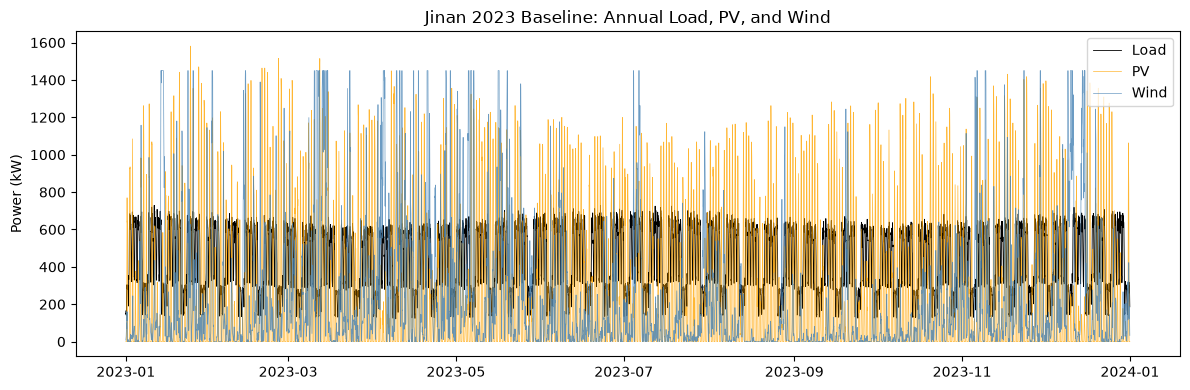

In [6]:
fig = plot_annual_profile(load, pv, wind, "Jinan 2023 Baseline: Annual Load, PV, and Wind")
save_figure(fig, FIGURES_DIR / "01_annual_profile.png")

INFO:src.visualization.plotting:Saved figure to /home/user/Leonardo-Assignment/outputs/figures/02_winter_week.png


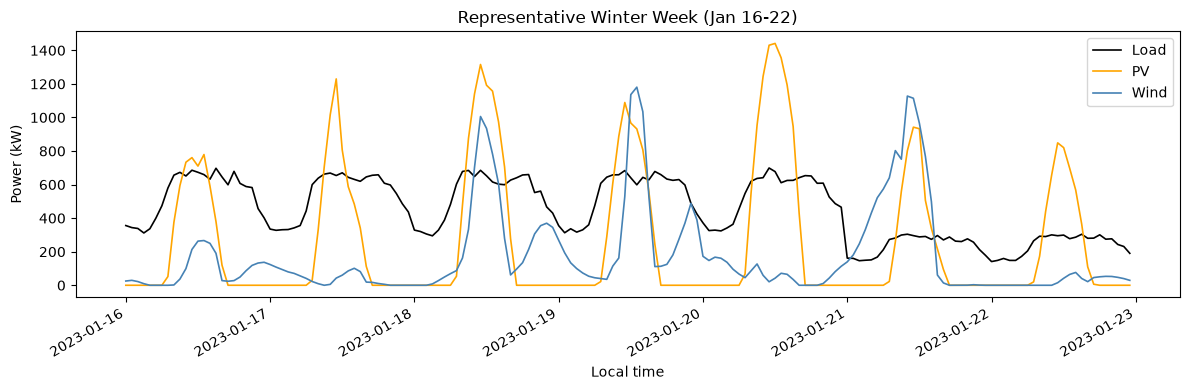

In [7]:
fig = plot_representative_week(load, pv, wind, "2023-01-16", "Representative Winter Week (Jan 16-22)")
save_figure(fig, FIGURES_DIR / "02_winter_week.png")

INFO:src.visualization.plotting:Saved figure to /home/user/Leonardo-Assignment/outputs/figures/03_summer_week.png


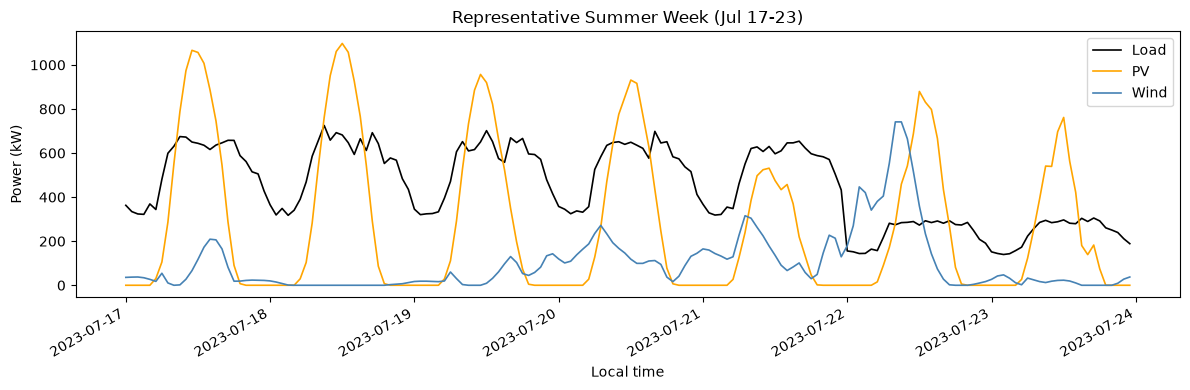

In [8]:
fig = plot_representative_week(load, pv, wind, "2023-07-17", "Representative Summer Week (Jul 17-23)")
save_figure(fig, FIGURES_DIR / "03_summer_week.png")

INFO:src.visualization.plotting:Saved figure to /home/user/Leonardo-Assignment/outputs/figures/04_load_duration_curve.png


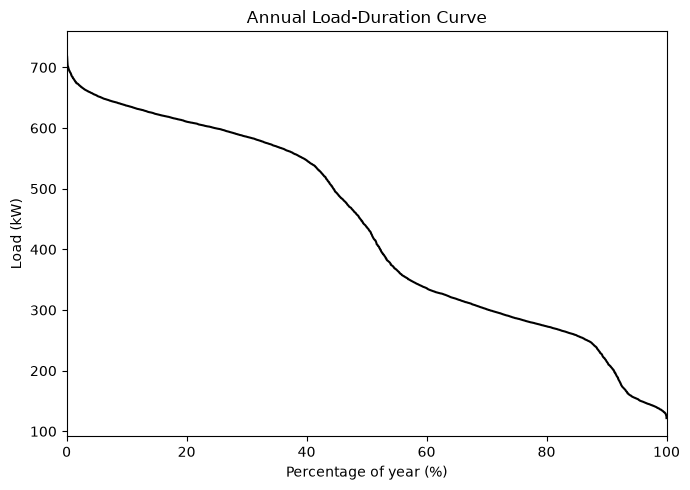

In [9]:
fig = plot_load_duration_curve(load)
save_figure(fig, FIGURES_DIR / "04_load_duration_curve.png")

INFO:src.visualization.plotting:Saved figure to /home/user/Leonardo-Assignment/outputs/figures/05_monthly_energy.png


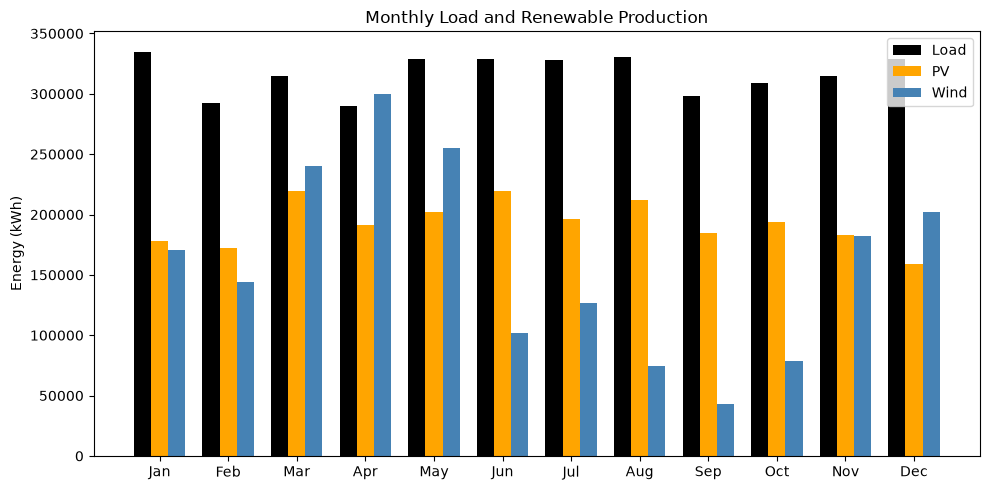

In [10]:
fig = plot_monthly_energy(load, pv, wind)
save_figure(fig, FIGURES_DIR / "05_monthly_energy.png")

INFO:src.visualization.plotting:Saved figure to /home/user/Leonardo-Assignment/outputs/figures/06_wind_speed_power_curve.png


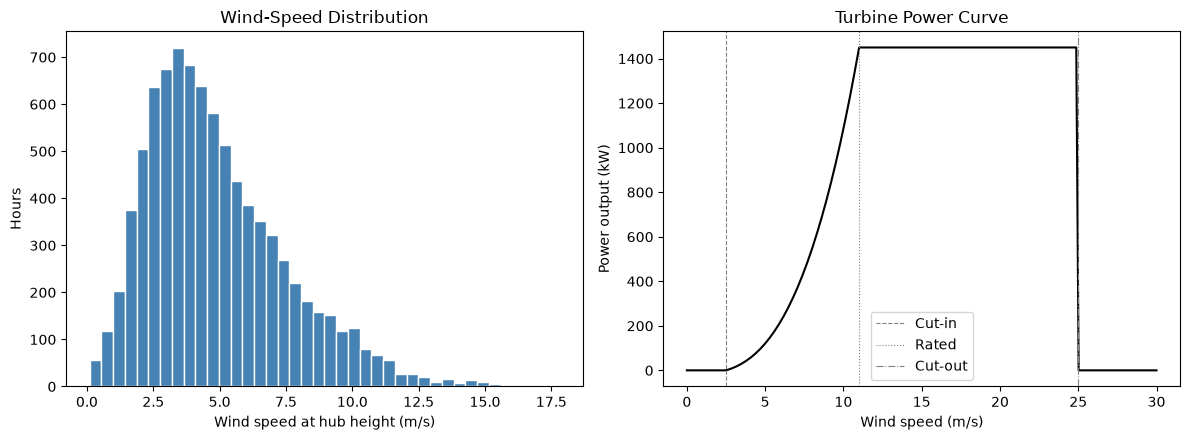

In [11]:
wind_speed_hub = adjust_wind_speed_to_hub_height(
    weather["WS10M"], config["wind"]["weather_reference_height_m"],
    config["wind"]["hub_height_m"], config["wind"]["wind_shear_exponent"],
)
fig = plot_wind_speed_distribution_and_power_curve(
    wind_speed_hub, config["wind"]["rated_power_kw"], config["wind"]["cut_in_mps"],
    config["wind"]["rated_mps"], config["wind"]["cut_out_mps"],
)
save_figure(fig, FIGURES_DIR / "06_wind_speed_power_curve.png")

## Next steps

Battery dispatch (`src.physics.dispatch`) and the exhaustive battery-size search (`src.physics.optimization`, Stage 3) will extend this notebook with: LPSP/curtailment/cost vs. battery capacity, representative SOC profiles, and the annual energy-flow balance (figures 7-11).

### Economic assumptions (PROJECT_BRIEF.md Addendum 3)

Every cost figure the diesel-backed system-LCOE search below uses -- PV/wind/battery/diesel installed costs, O&M fractions, economic lifetimes, the diesel fuel price and fuel curve, and the real discount rate -- is a **documented modelling/economic assumption**, not an official price quote or manufacturer spec (`config/jinan.yaml`). Tabulated here directly from the loaded config (never hardcoded in this notebook) so the table always reflects whatever values actually drove this run.

In [12]:
from src.physics.economics import economic_assumptions_table

assumptions = economic_assumptions_table(config)
assumptions.to_csv(TABLES_DIR / "economic_assumptions.csv", index=False)
assumptions[["technology", "parameter", "value", "unit", "source_basis"]]

,technology,parameter,value,unit,source_basis
0,PV,installed_cost_eur_per_kwp,700,EUR/kWp,2024 global utility-scale weighted-average ins...
1,PV,om_cost_fraction_per_year,0.015,fraction of capital/year,Standard O&M assumption (~1.5%/year)
2,PV,economic_lifetime_years,25,years,Typical PV module warranty/economic-life assum...
3,Wind,installed_cost_eur_per_kw,1200,EUR/kW,Between utility-scale onshore wind's global we...
4,Wind,om_cost_fraction_per_year,0.025,fraction of capital/year,Standard O&M assumption (~2.5%/year)
5,Wind,economic_lifetime_years,20,years,Typical turbine design-life assumption
6,Battery,installed_cost_eur_per_kwh,300,EUR/kWh,C&I/utility-scale LFP economies of scale vs. t...
7,Battery,cost_sensitivity_eur_per_kwh,"[220, 300, 400]",EUR/kWh (list),Documented alternative values for a future bat...
8,Battery,economic_lifetime_years,10,years,Economic assumption -- replaced once within th...
9,Battery,project_lifetime_years,20,years,"Economic assumption, shared project horizon ac..."


## Battery-size optimization (Stage 3)

Exhaustive search over the configured candidate module range (`config/jinan.yaml` -> `battery.candidate_module_counts`, 0-80 modules) against the fixed baseline PV (1,800 kWp) and wind (1,450 kW) capacities. **Objective, per PROJECT_BRIEF.md Addendum 3:** select the battery capacity minimizing total system LCOE (PV+wind+battery+diesel capital/O&M/fuel per kWh served), with a diesel generator (rated at 1.25x peak load, `config/jinan.yaml` -> `diesel`) backstopping reliability. LPSP and renewable share are reported metrics, not the search objective -- see the module docstring in `src/physics/optimization.py` for why diesel removes the hard feasibility constraint the pre-Addendum-3 build used.

In [13]:
from src.physics.optimization import run_battery_search

battery_cfg = config["battery"]
search_result = run_battery_search(
    pv, wind, load,
    n_max=battery_cfg["candidate_module_counts"]["max"],
    module_capacity_kwh=battery_cfg["module_capacity_kwh"],
    module_rated_power_kw=battery_cfg["module_rated_power_kw"],
    round_trip_efficiency=battery_cfg["round_trip_efficiency"],
    min_soc_fraction=battery_cfg["min_soc_fraction"],
    max_soc_fraction=battery_cfg["max_soc_fraction"],
    initial_soc_fraction=battery_cfg["initial_soc_fraction"],
    installed_cost_eur_per_kwh=battery_cfg["installed_cost_eur_per_kwh"],
    economic_lifetime_years=battery_cfg["economic_lifetime_years"],
    project_lifetime_years=battery_cfg["project_lifetime_years"],
    real_discount_rate=config["economics"]["real_discount_rate"],
    pv_capacity_kwp=config["pv"]["capacity_kwp"],
    pv_cfg=config["pv"],
    wind_capacity_kw=config["wind"]["rated_power_kw"],
    wind_cfg=config["wind"],
    diesel_cfg=config["diesel"],
    lpsp_target=config["reliability"]["primary_lpsp_target"],
    reliability_sensitivity_targets=config["reliability"]["sensitivity_targets_load_served"],
)

print(f"Meets reliability target with diesel backup: {search_result.feasible}")
print(f"System-LCOE-optimal: {search_result.optimal_n_modules} modules "
      f"({search_result.optimal_capacity_kwh:.1f} kWh), "
      f"LCOE={search_result.system_lcoe_eur_per_kwh:.4f} EUR/kWh, "
      f"renewable share={search_result.renewable_share:.1%}, "
      f"LPSP (post-diesel)={search_result.lpsp:.6f}")
if not search_result.feasible:
    print(search_result.infeasibility_reason)
print(f"Search runtime: {search_result.search_runtime_seconds:.2f} s "
      f"for {len(search_result.candidates)} candidates "
      f"({search_result.search_runtime_seconds / len(search_result.candidates):.4f} s/candidate)")

search_result.candidates.to_csv(TABLES_DIR / "baseline_battery_candidate_results.csv", index=False)
search_result.reliability_sensitivity.to_csv(TABLES_DIR / "baseline_reliability_sensitivity.csv", index=False)
search_result.candidates[["n_modules", "nominal_battery_capacity_kwh", "lpsp", "lpsp_after_diesel",
                          "renewable_share", "system_lcoe_eur_per_kwh", "diesel_annual_energy_kwh",
                          "equivalent_annual_cost_eur"]]

Meets reliability target with diesel backup: True
System-LCOE-optimal: 19 modules (4750.0 kWh), LCOE=0.2390 EUR/kWh, renewable share=80.2%, LPSP (post-diesel)=0.000000
Search runtime: 0.81 s for 81 candidates (0.0100 s/candidate)


,n_modules,nominal_battery_capacity_kwh,lpsp,lpsp_after_diesel,renewable_share,system_lcoe_eur_per_kwh,diesel_annual_energy_kwh,equivalent_annual_cost_eur
0,0,0.0,0.410659,0.0,0.589341,0.287448,1.560504e+06,0.000000
1,1,250.0,0.391359,0.0,0.608641,0.281265,1.487163e+06,9712.843122
2,2,500.0,0.373840,0.0,0.626160,0.275864,1.420592e+06,19425.686245
3,3,750.0,0.357638,0.0,0.642362,0.270982,1.359025e+06,29138.529367
4,4,1000.0,0.342432,0.0,0.657568,0.266848,1.301240e+06,38851.372490
...,...,...,...,...,...,...,...,...
76,76,19000.0,0.103026,0.0,0.896974,0.341703,3.914996e+05,738176.077303
77,77,19250.0,0.102427,0.0,0.897573,0.343985,3.892213e+05,747888.920426
78,78,19500.0,0.101827,0.0,0.898173,0.346303,3.869430e+05,757601.763548
79,79,19750.0,0.101228,0.0,0.898772,0.348603,3.846647e+05,767314.606670


### Is the fixed baseline generation adequate?

Checking the annual energy balance and the monthly renewable-to-load ratio directly, since LPSP alone doesn't distinguish "not enough energy, ever" from "enough energy overall, but poorly timed."

In [14]:
annual_renewable_kwh = pv.sum() + wind.sum()
annual_load_kwh = load.sum()
print(f"Annual renewable production: {annual_renewable_kwh:.0f} kWh")
print(f"Annual load: {annual_load_kwh:.0f} kWh")
print(f"Annual ratio: {annual_renewable_kwh / annual_load_kwh:.3f}")

monthly = pd.DataFrame({"renewable_kwh": pv + wind, "load_kwh": load}).resample("MS").sum()
monthly["ratio"] = monthly["renewable_kwh"] / monthly["load_kwh"]
monthly["ratio"]

Annual renewable production: 4232266 kWh
Annual load: 3800000 kWh
Annual ratio: 1.114


2023-01-01 00:00:00+08:00    1.042036
2023-02-01 00:00:00+08:00    1.079829
2023-03-01 00:00:00+08:00    1.463154
2023-04-01 00:00:00+08:00    1.693724
2023-05-01 00:00:00+08:00    1.390650
2023-06-01 00:00:00+08:00    0.977329
2023-07-01 00:00:00+08:00    0.984258
2023-08-01 00:00:00+08:00    0.867340
2023-09-01 00:00:00+08:00    0.763141
2023-10-01 00:00:00+08:00    0.883373
2023-11-01 00:00:00+08:00    1.157980
2023-12-01 00:00:00+08:00    1.099000
Freq: MS, Name: ratio, dtype: float64

**Finding:** annual renewable production (~4,232,266 kWh) exceeds annual load (~3,800,000 kWh) by 11.4%, but five consecutive months (June-October) run a monthly deficit -- a **seasonal generation/load mismatch**, same underlying pattern as the pre-diesel Addendum 2 build found. Under that build's hard LPSP constraint, this made the system infeasible within the configured 0-80 module range (LPSP never dropped below ~10%). Under Addendum 3's diesel-backed min-LCOE objective, diesel simply covers the seasonal shortfall whenever it's cheaper to burn fuel than to buy more battery capacity -- the search above reports the battery capacity that minimizes total system LCOE given that trade-off, and the renewable-share-vs-LCOE sweep below (figure 28) shows the full trade-off curve, not just the single optimal point.

### Diagnostic-only extended search (not the baseline result)

Checking whether extending the search range beyond the configured 0-80 modules would find a lower system LCOE -- i.e. whether the configured range is wide enough to actually capture the LCOE minimum, not an artifact of an arbitrarily truncated range:

In [15]:
diagnostic_result = run_battery_search(
    pv, wind, load, n_max=200,
    module_capacity_kwh=battery_cfg["module_capacity_kwh"],
    module_rated_power_kw=battery_cfg["module_rated_power_kw"],
    round_trip_efficiency=battery_cfg["round_trip_efficiency"],
    min_soc_fraction=battery_cfg["min_soc_fraction"],
    max_soc_fraction=battery_cfg["max_soc_fraction"],
    initial_soc_fraction=battery_cfg["initial_soc_fraction"],
    installed_cost_eur_per_kwh=battery_cfg["installed_cost_eur_per_kwh"],
    economic_lifetime_years=battery_cfg["economic_lifetime_years"],
    project_lifetime_years=battery_cfg["project_lifetime_years"],
    real_discount_rate=config["economics"]["real_discount_rate"],
    pv_capacity_kwp=config["pv"]["capacity_kwp"],
    pv_cfg=config["pv"],
    wind_capacity_kw=config["wind"]["rated_power_kw"],
    wind_cfg=config["wind"],
    diesel_cfg=config["diesel"],
    lpsp_target=config["reliability"]["primary_lpsp_target"],
)
print(f"Extended search (0-200 modules): optimal at {diagnostic_result.optimal_n_modules} modules, "
      f"LCOE={diagnostic_result.system_lcoe_eur_per_kwh:.4f} EUR/kWh")
print(f"Baseline 0-80 search found: {search_result.optimal_n_modules} modules, "
      f"LCOE={search_result.system_lcoe_eur_per_kwh:.4f} EUR/kWh")
if diagnostic_result.optimal_n_modules == search_result.optimal_n_modules:
    print("Configured 0-80 range already captures the true system-LCOE minimum.")
else:
    print("Extending beyond 80 modules changes the optimum -- configured range may be too narrow.")

Extended search (0-200 modules): optimal at 19 modules, LCOE=0.2390 EUR/kWh
Baseline 0-80 search found: 19 modules, LCOE=0.2390 EUR/kWh
Configured 0-80 range already captures the true system-LCOE minimum.


### Required figures (PROJECT_BRIEF.md §27, mechanistic figures 7-11)

INFO:src.visualization.plotting:Saved figure to /home/user/Leonardo-Assignment/outputs/figures/07_lpsp_vs_capacity.png


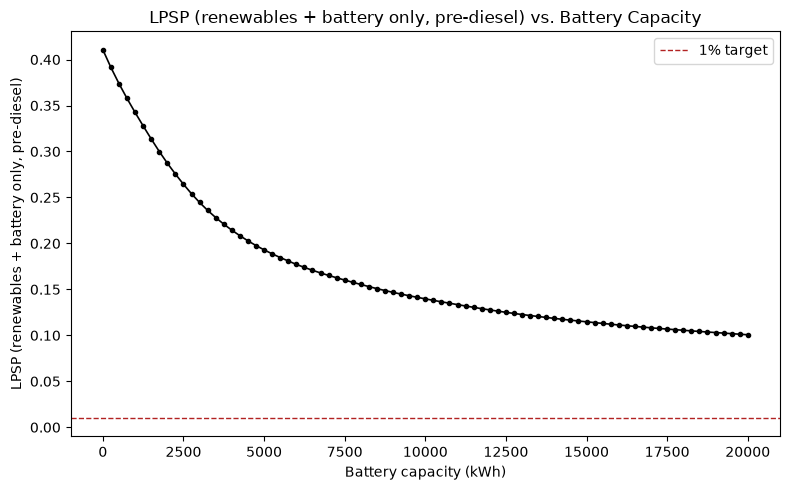

In [16]:
fig = plot_metric_vs_battery_capacity(
    search_result.candidates, "lpsp", "LPSP (renewables + battery only, pre-diesel)",
    target_line=config["reliability"]["primary_lpsp_target"], target_label="1% target",
)
save_figure(fig, FIGURES_DIR / "07_lpsp_vs_capacity.png")

INFO:src.visualization.plotting:Saved figure to /home/user/Leonardo-Assignment/outputs/figures/08_curtailment_vs_capacity.png


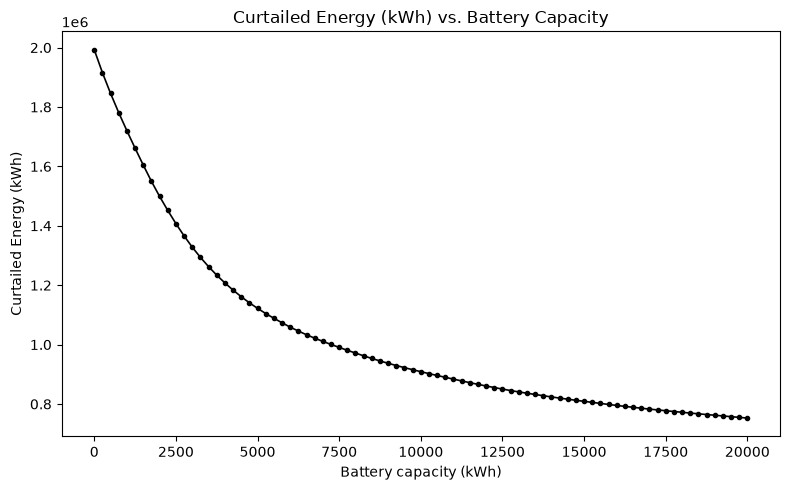

In [17]:
fig = plot_metric_vs_battery_capacity(search_result.candidates, "curtailed_energy_kwh", "Curtailed Energy (kWh)")
save_figure(fig, FIGURES_DIR / "08_curtailment_vs_capacity.png")

INFO:src.visualization.plotting:Saved figure to /home/user/Leonardo-Assignment/outputs/figures/09_cost_vs_capacity.png


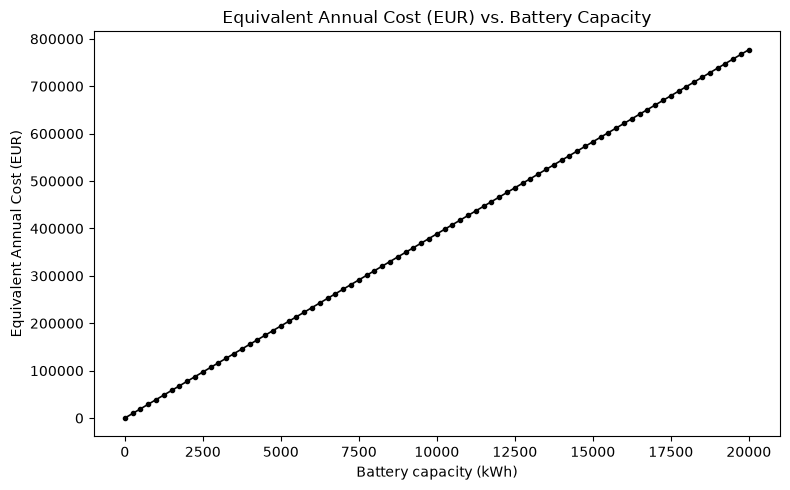

In [18]:
fig = plot_metric_vs_battery_capacity(search_result.candidates, "equivalent_annual_cost_eur", "Equivalent Annual Cost (EUR)")
save_figure(fig, FIGURES_DIR / "09_cost_vs_capacity.png")

### System LCOE and renewable-share trade-off (PROJECT_BRIEF.md Addendum 3, figures 27-28)

Figure 27 is the direct system-wide analogue of figure 09 above (which shows only the battery's own equivalent annual cost). Figure 28 reproduces the course lecture's OptiCE "Typical results (1)" chart shape (renewable share % vs. LCOE $/kWh) directly from this project's own exhaustive battery search for the baseline case -- one fixed PV/wind combination swept over battery capacity, rather than OptiCE's own joint PV/wind/battery genetic-algorithm sweep (a documented scope difference, `reports/technical_report.md` Related Work/Limitations).

INFO:src.visualization.plotting:Saved figure to /home/user/Leonardo-Assignment/outputs/figures/27_system_lcoe_vs_capacity.png


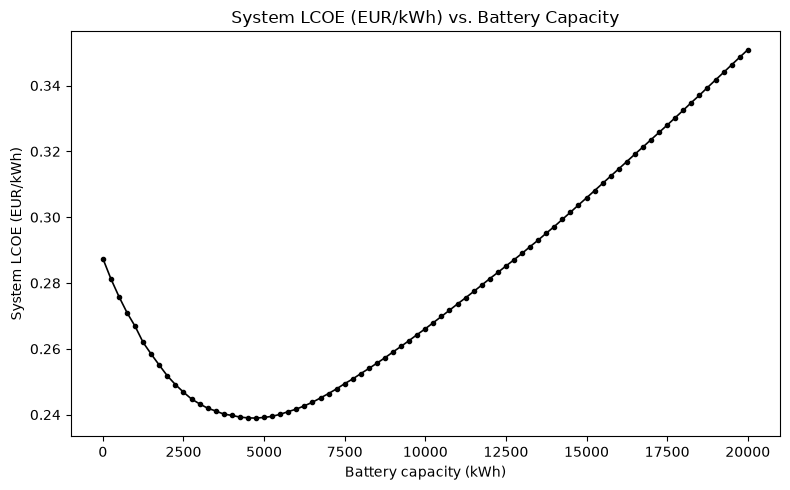

In [19]:
fig = plot_metric_vs_battery_capacity(search_result.candidates, "system_lcoe_eur_per_kwh", "System LCOE (EUR/kWh)")
save_figure(fig, FIGURES_DIR / "27_system_lcoe_vs_capacity.png")

INFO:src.visualization.plotting:Saved figure to /home/user/Leonardo-Assignment/outputs/figures/28_renewable_share_vs_lcoe.png


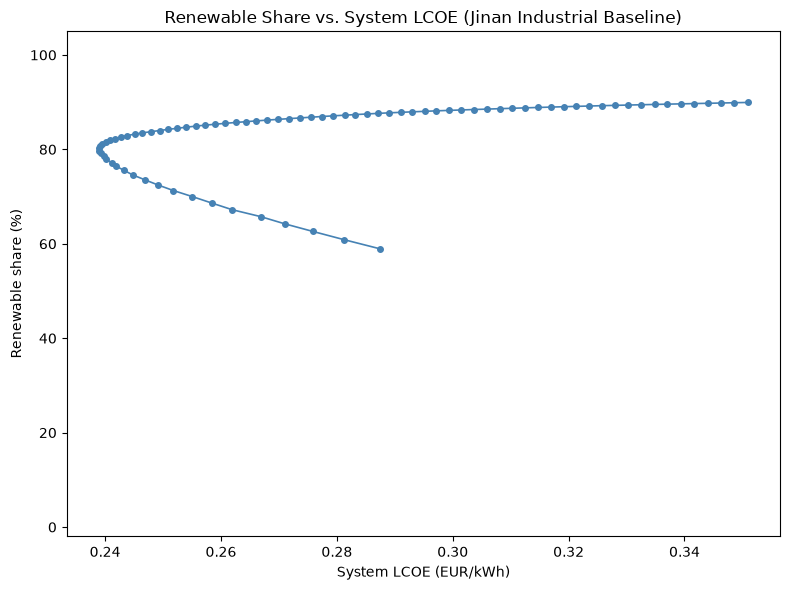

In [20]:
from src.visualization.plotting import plot_renewable_share_vs_lcoe

fig = plot_renewable_share_vs_lcoe(
    search_result.candidates,
    title="Renewable Share vs. System LCOE (Jinan Industrial Baseline)",
)
save_figure(fig, FIGURES_DIR / "28_renewable_share_vs_lcoe.png")

SOC profile and energy-flow balance are illustrated using the **system-LCOE-optimal candidate** (`search_result.optimal_n_modules`), since Addendum 3's diesel-backed min-LCOE objective always yields a genuine optimum within the configured search range (diesel guarantees feasibility by construction -- see `src/physics/optimization.py` module docstring), unlike the pre-Addendum-3 build where the largest tested candidate had to stand in for a nonexistent optimum.

INFO:src.visualization.plotting:Saved figure to /home/user/Leonardo-Assignment/outputs/figures/10_soc_profile.png


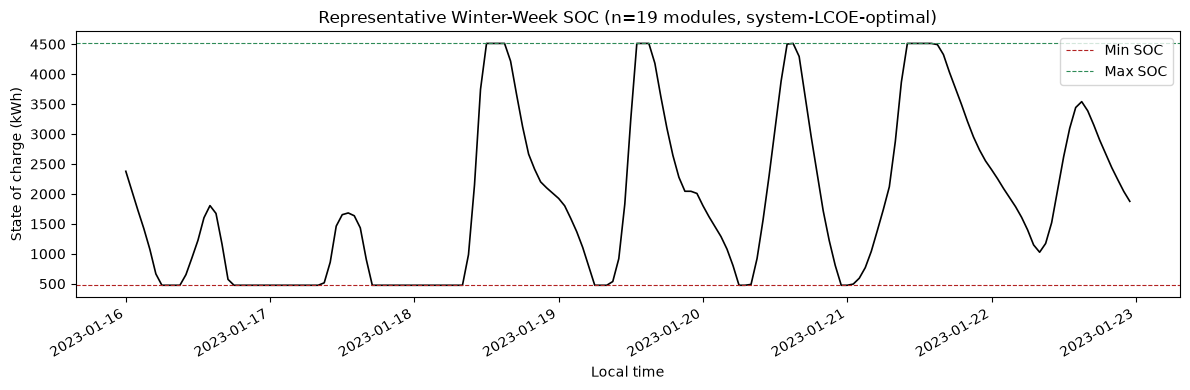

In [21]:
from src.physics.battery import BatterySpec
from src.physics.dispatch import resolve_initial_soc_bias
from src.physics.diesel import DieselSpec, apply_diesel_backup, diesel_rated_power_kw
from src.visualization.plotting import plot_soc_profile

optimal_battery = BatterySpec(
    module_capacity_kwh=battery_cfg["module_capacity_kwh"],
    module_rated_power_kw=battery_cfg["module_rated_power_kw"],
    round_trip_efficiency=battery_cfg["round_trip_efficiency"],
    min_soc_fraction=battery_cfg["min_soc_fraction"],
    max_soc_fraction=battery_cfg["max_soc_fraction"],
    initial_soc_fraction=battery_cfg["initial_soc_fraction"],
    n_modules=search_result.optimal_n_modules,
)
optimal_dispatch = resolve_initial_soc_bias(pv, wind, load, optimal_battery)

diesel_cfg = config["diesel"]
diesel_spec = DieselSpec(
    rated_power_kw=diesel_rated_power_kw(float(load.max()), diesel_cfg["sizing_factor"]),
    fuel_curve_intercept_l_per_kwh_rated=diesel_cfg["fuel_curve_intercept_l_per_kwh_rated"],
    fuel_curve_slope_l_per_kwh_output=diesel_cfg["fuel_curve_slope_l_per_kwh_output"],
    fuel_price_eur_per_l=diesel_cfg["fuel_price_eur_per_l"],
    installed_cost_eur_per_kw=diesel_cfg["installed_cost_eur_per_kw"],
    om_cost_fraction_per_year=diesel_cfg["om_cost_fraction_per_year"],
    economic_lifetime_years=diesel_cfg["economic_lifetime_years"],
    project_lifetime_years=diesel_cfg["project_lifetime_years"],
)
optimal_dispatch_with_diesel = apply_diesel_backup(optimal_dispatch, diesel_spec)
optimal_dispatch_with_diesel.to_csv(TABLES_DIR / "baseline_optimal_hourly_dispatch.csv", index_label="timestamp")

fig = plot_soc_profile(
    optimal_dispatch_with_diesel, "2023-01-16",
    optimal_battery.min_soc_kwh, optimal_battery.max_soc_kwh,
    f"Representative Winter-Week SOC (n={optimal_battery.n_modules} modules, system-LCOE-optimal)",
)
save_figure(fig, FIGURES_DIR / "10_soc_profile.png")

INFO:src.visualization.plotting:Saved figure to /home/user/Leonardo-Assignment/outputs/figures/11_energy_flow_balance.png


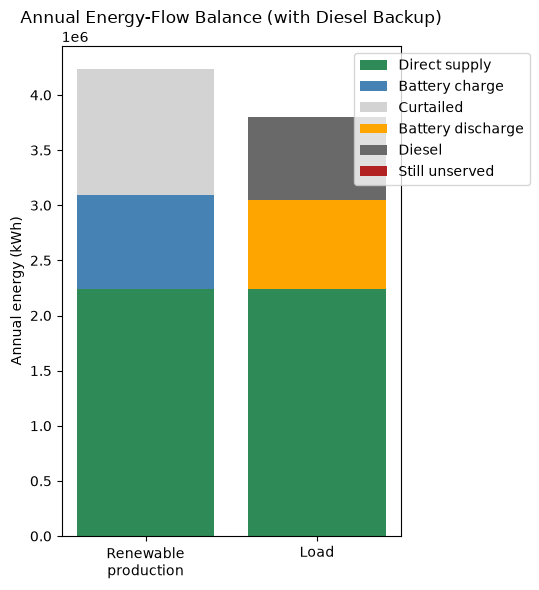

In [22]:
from src.visualization.plotting import plot_energy_flow_balance_with_diesel

fig = plot_energy_flow_balance_with_diesel(optimal_dispatch_with_diesel)
save_figure(fig, FIGURES_DIR / "11_energy_flow_balance.png")

## Stage 3 summary

- Per PROJECT_BRIEF.md Addendum 3, the mechanistic exhaustive search now selects the battery capacity minimizing total system LCOE (PV + wind + battery + diesel capital/O&M/fuel per kWh served), with a diesel generator (rated at 1.25x peak load) backstopping any residual unserved energy. This replaces the pre-Addendum-3 hard LPSP-constrained search.
- **Result (Jinan industrial baseline, 1,800 kWp PV + 1,450 kW wind): the system-LCOE-optimal battery is 19 modules (4,750 kWh nominal capacity), system LCOE = 0.2390 EUR/kWh, renewable share = 80.2%, LPSP after diesel = 0.000000 (fully reliable).** The configured 0-80 module search range was verified sufficient: an extended diagnostic search over 0-200 modules found the same optimum (19 modules), confirming the LCOE-vs-capacity curve is genuinely convex over the configured range rather than being truncated by it.
- The system LCOE curve (figure 27) is U-shaped: at zero battery capacity LCOE is 0.287 EUR/kWh (heavy diesel reliance), falls to its minimum of 0.2390 EUR/kWh at 19 modules as battery capacity substitutes for diesel fuel, then rises again beyond ~19 modules as additional battery capital cost outweighs the shrinking diesel-fuel savings. Renewable share keeps climbing monotonically with battery capacity (to 89.9% at 80 modules) even as LCOE rises past its minimum -- reproducing the same qualitative trade-off shown in the course lecture's OptiCE chart (figure 28), where the minimum-LCOE point sits at a renewable share well below 100%.
- The seasonal (monthly-scale) generation/load mismatch identified above (June-October deficit months) persists as a physical characteristic of the site; under Addendum 3 it no longer causes infeasibility, but it directly drives the diesel fuel consumption that keeps the optimal renewable share at 80.2% rather than near 100%.

**Carried into Stage 4 (scenario generation):** scenarios are no longer at risk of being reported as infeasible purely due to a narrow battery search range, since diesel guarantees feasibility by construction. `optimal_capacity_kwh` labels now represent the system-LCOE-minimizing capacity, not an LPSP-constrained one; the scenario sampler and ML pipeline (`src.scenarios`, `src.ai`) consume this new label definition unchanged in interface but changed in meaning.